# Allen 10x differential expression: dorsolateral vs ventromedial AON glutamatergic neurons

The biological question is the molecular identity of the **dorsolateral, contralaterally-projecting**
AON glutamatergic population. Prior viral tracing places this projection-dense population in
the dorsolateral AON (with Illig & Eudy 2009, J Comp Neurol corroborating a dorsolateral bias on the receiving
side), and the eight candidate markers were defined from a dorsolateral (Target)
vs ventromedial (Non-target) contrast. This notebook restores that contrast as the primary result,
carried onto the genome-wide Allen 10x Whole Mouse Brain data (MERFISH measures only ~500 genes).

The two spatial axes from `03_abca_spatial.ipynb` are each tested for what they are:

- **Primary: dorsolateral vs ventromedial** (cluster-level, from
  `results/tables/spatial_cluster_dl_assignment.csv`). The projection-relevant contrast. Projection status
  is not measured here, so a dorsolateral position is a spatial proxy, not a readout.
- **Robustness: posterior vs anterior** (supertype-level). The dominant *molecular* axis, reported
  to show the candidate signal is not an artifact of one grouping and that anteroposterior remains
  the stronger overall axis.
- **Robustness: a prior hand-picked Target/Non-target lists**, reported with the caveat that
  they are projection-hypothesis-driven rather than a clean spatial partition.

Design choices:

1. **Join key.** Cells are matched on the unique `cell_label`, not the reused 16 bp barcode.
2. **Statistics.** Donor-level pseudobulk DESeq2 on raw counts, not a cell-level test. Nuclei from
   one mouse are not independent replicates, so the donor is the unit of replication.
3. **Single chemistry.** Restricted to the 10x v2 OLF matrix to avoid a cross-chemistry batch
   effect. This is the main statistical limitation.
4. **Reproducible grouping.** All group labels are loaded from the spatial notebook's exports, not
   hand-assigned here.

In [1]:
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import yaml
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

ROOT = Path("..")
with open(ROOT / "config/config.yaml") as fh:
    cfg = yaml.safe_load(fh)
paths = cfg["paths"]
de = cfg["de"]
FDR = de["fdr"]
LOG2FC = de["log2fc"]
MIN_CELLS = de["min_cells"]
MIN_COUNT = de["min_count"]
MIN_CELLS_SWEEP = de["min_cells_sweep"]

RAW_MATRIX = ROOT / paths["allen_raw_matrix"]
CELL_META = ROOT / paths["allen_10x_meta"]
CANDIDATE_GENES = ROOT / paths["candidate_genes"]

OUTPUT_DIR = ROOT / paths["results_dir"]
OUTPUT_DIR.mkdir(exist_ok=True)
FIG_DIR = OUTPUT_DIR / "figures_raw"
TAB_DIR = OUTPUT_DIR / "tables"
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

In [2]:
import plotting_style as ps

ps.apply_style()

In [3]:
import subprocess

import pydeseq2

_git_hash = subprocess.check_output(["git", "rev-parse", "--short", "HEAD"], cwd="..").decode().strip()
print(f"git commit : {_git_hash}")
print(f"scanpy     : {sc.__version__}")
print(f"pydeseq2   : {pydeseq2.__version__}")

git commit : b473fae
scanpy     : 1.11.5
pydeseq2   : 0.5.4


## Grouping

Load the three groupings exported by `03_abca_spatial.ipynb` (see the intro for which is primary):
the dorsolateral/ventromedial split (`spatial_cluster_dl_assignment.csv`), posterior/anterior
(`spatial_group_assignment.csv`), and the prior hand-picked Target/Non-target lists.

In [4]:
# Primary grouping: cluster -> dorsolateral/ventromedial, from the spatial notebook's export
# (03_abca_spatial.ipynb) so the assignment is reproducible, not hand-coded here.
dl_map = pd.read_csv(TAB_DIR / "spatial_cluster_dl_assignment.csv")
cluster_dl_group = dict(zip(dl_map["cluster"], dl_map["group"]))
print("Primary dorsolateral/ventromedial cluster grouping (top rows by dl_score):")
print(dl_map[["cluster", "n", "med_dl_score", "group"]].head(6).to_string(index=False))

# Robustness grouping 1: supertype -> posterior/anterior (the dominant molecular axis).
ap_map = pd.read_csv(TAB_DIR / "spatial_group_assignment.csv")
supertype_group = dict(zip(ap_map["supertype"], ap_map["group"]))

# Robustness grouping 2: a prior hand-picked Target (dorsolateral) / Non-target (ventromedial)
# sub-cluster lists. Projection-hypothesis-driven, not a clean spatial partition: it labels 0175
# (a dorsal Glut_3) as Non-target, which the coordinate-based score places dorsolateral.
alt_target_clusters = [
    "0184 IT AON-TT-DP Glut_5", "0183 IT AON-TT-DP Glut_5", "0180 IT AON-TT-DP Glut_4",
    "0177 IT AON-TT-DP Glut_3", "0181 IT AON-TT-DP Glut_4",
]
alt_nontarget_clusters = [
    "0171 IT AON-TT-DP Glut_2", "0172 IT AON-TT-DP Glut_2", "0173 IT AON-TT-DP Glut_2",
    "0170 IT AON-TT-DP Glut_1", "0175 IT AON-TT-DP Glut_3",
]


Primary dorsolateral/ventromedial cluster grouping (top rows by dl_score):
                 cluster    n  med_dl_score        group
0175 IT AON-TT-DP Glut_3  892      1.228361 dorsolateral
0176 IT AON-TT-DP Glut_3  428      0.952815 dorsolateral
0178 IT AON-TT-DP Glut_3 1365      0.762529 dorsolateral
0182 IT AON-TT-DP Glut_5  777      0.583480 dorsolateral
0184 IT AON-TT-DP Glut_5 7859      0.530699 dorsolateral
0185 IT AON-TT-DP Glut_5  847      0.471561 dorsolateral


## Load raw counts and assign the dorsolateral/ventromedial group

The expression matrix is opened in backed mode so only AON glutamatergic cells are read into
memory. Each cell carries its cluster label. The cluster maps to dorsolateral/ventromedial (primary)
and its supertype maps to posterior/anterior (robustness). Cluster, donor, and sex are joined from
the cell metadata on the unique `cell_label`, with explicit integrity checks.


In [5]:
meta = pd.read_csv(
    CELL_META, usecols=["cell_label", "cluster", "donor_label", "donor_sex"]
).set_index("cell_label")
assert meta.index.is_unique, "cell_label is expected to be unique"

backed = ad.read_h5ad(RAW_MATRIX, backed="r")
cluster = meta["cluster"].reindex(backed.obs.index)

# Restrict to AON glutamatergic cells, map cluster -> dorsolateral/ventromedial (primary) and
# supertype -> posterior/anterior (robustness).
is_aon = cluster.fillna("").str.contains("IT AON-TT-DP Glut")
supertype = cluster.str.extract(r"(Glut_\d+)$", expand=False)
dl_grp = cluster.map(cluster_dl_group)
ap_grp = supertype.map(supertype_group)
mask = (is_aon & dl_grp.notna()).values

adata = backed[mask].to_memory()
adata.obs["cluster"] = cluster.reindex(adata.obs.index).values
adata.obs["supertype"] = supertype.reindex(adata.obs.index).values
adata.obs["donor_label"] = meta["donor_label"].reindex(adata.obs.index).values
adata.obs["donor_sex"] = meta["donor_sex"].reindex(adata.obs.index).values
adata.obs["dl_group"] = pd.Categorical(dl_grp[mask].values,
                                       categories=["ventromedial", "dorsolateral"])
adata.obs["ap_group"] = pd.Categorical(ap_grp[mask].values,
                                       categories=["anterior", "posterior"])
adata.obs["group"] = adata.obs["dl_group"]  # primary contrast
del backed

assert adata.obs[["cluster", "donor_label", "group"]].notna().all().all(), "unannotated cells after join"

rng = np.random.default_rng(0)
check = adata.X[rng.choice(adata.n_obs, size=min(500, adata.n_obs), replace=False)].toarray()
print(f"Counts are integer-valued: {np.allclose(check, np.round(check))}")
print(f"Dorsolateral cells: {(adata.obs['group'] == 'dorsolateral').sum():,}")
print(f"Ventromedial cells: {(adata.obs['group'] == 'ventromedial').sum():,}")
print(f"Donors: {adata.obs['donor_label'].nunique()}")


Counts are integer-valued: True
Dorsolateral cells: 17,311
Ventromedial cells: 11,019
Donors: 16


## Candidate marker overview

The eight projection-candidate markers, shown across the dorsolateral/ventromedial split
as a first look before the formal DESeq2 test.


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


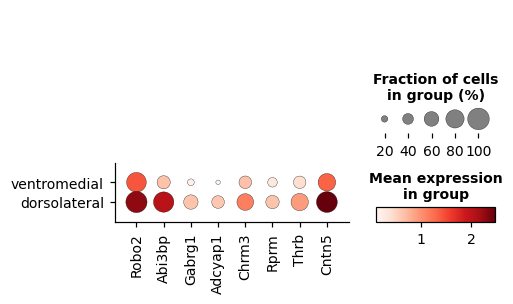

In [6]:
viz = adata.copy()
sc.pp.normalize_total(viz, target_sum=1e4)
sc.pp.log1p(viz)

candidate_genes = ["Robo2", "Abi3bp", "Gabrg1", "Adcyap1", "Chrm3", "Rprm", "Thrb", "Cntn5"]
present = [g for g in candidate_genes if g in set(viz.var["gene_symbol"])]
sc.pl.dotplot(viz, var_names=present, gene_symbols="gene_symbol", groupby="group")

## Canonical projection panel (negative control)

The candidates were selected as putatively AON-relevant and are dorsolateral-enriched here,
which is what motivates the projection framing. Scored against the *established* cortical
projection-neuron panel (callosal/IT, subcerebral, midline-guidance markers), however, the DE result
shows **no coherent projection-class signature**. The classes split in both directions rather than
tracking the dorsolateral axis. This is consistent with olfactory-cortex glutamatergic neurons
co-expressing deep and superficial cortical programs and forming a continuous rather than discretely
projection-typed identity (Brunjes & Osterberg 2015, PLOS ONE; Zeppilli et al. 2025, Nat Neurosci). The candidate markers are
therefore suggestive of a dorsolateral molecular identity, not a projection readout. A definitive
test needs retrograde tracing. The figure below carries the per-gene values.

## Pseudobulk aggregation

Sum raw counts per (donor, group), dropping profiles built from fewer than 10 cells as too noisy.

In [7]:
def build_pseudobulk(adata, min_cells=MIN_CELLS):
    """Sum raw counts within each donor-by-group combination.

    Returns a counts DataFrame (samples x genes) and a sample metadata frame
    carrying donor, group, sex, and the number of cells aggregated.
    """
    counts, sample_meta = [], []
    for (donor, grp), df in adata.obs.groupby(["donor_label", "group"], observed=True):
        counts.append(np.asarray(adata[df.index].X.sum(axis=0)).ravel())
        sample_meta.append({
            "donor": donor,
            "group": grp,
            "sex": adata.obs.loc[df.index, "donor_sex"].iloc[0],
            "n_cells": len(df),
        })
    counts = pd.DataFrame(counts, columns=adata.var_names)
    sample_meta = pd.DataFrame(sample_meta)
    keep = sample_meta["n_cells"] >= min_cells
    return counts[keep.values].reset_index(drop=True), sample_meta[keep].reset_index(drop=True)


pb_counts, pb_meta = build_pseudobulk(adata)
print(f"Pseudobulk profiles (>= {MIN_CELLS} cells): {len(pb_meta)}")
print(pb_meta.groupby("group", observed=True)["n_cells"].agg(["count", "min", "median", "max"]))

Pseudobulk profiles (>= 10 cells): 25
              count  min  median   max
group                                 
dorsolateral     11   10    80.0  7325
ventromedial     14   13    55.5  4159


In [8]:
def paired_deseq2(pb_counts, pb_meta, pos_label, neg_label, min_count=MIN_COUNT):
    """Paired ~donor+group DESeq2 on (donor x group) pseudobulk.

    Restricts to donors present in both groups, applies a group-aware >= min_count filter, fits the
    within-donor model with neg_label as the reference level, and returns
    (results_df with symbol, significant_df, n_paired_donors, n_samples, counts, clin). A positive
    log2FoldChange means up in pos_label.
    """
    paired = (set(pb_meta.loc[pb_meta["group"] == pos_label, "donor"])
              & set(pb_meta.loc[pb_meta["group"] == neg_label, "donor"]))
    m = pb_meta["donor"].isin(paired).values
    counts = pb_counts[m].reset_index(drop=True)
    clin = pb_meta[m].reset_index(drop=True).copy()
    clin["group"] = pd.Categorical(clin["group"], categories=[neg_label, pos_label])
    clin["donor"] = pd.Categorical(clin["donor"])
    is_pos = (clin["group"] == pos_label).values
    keep = (counts[is_pos].sum(axis=0) >= min_count) & (counts[~is_pos].sum(axis=0) >= min_count)
    counts = counts.loc[:, keep.values].round().astype(int)
    dds = DeseqDataSet(counts=counts, metadata=clin, design="~donor+group", quiet=True)
    dds.deseq2()
    stat = DeseqStats(dds, contrast=["group", pos_label, neg_label], quiet=True)
    stat.summary()
    res = stat.results_df.dropna().copy()
    res["symbol"] = adata.var["gene_symbol"].reindex(res.index).fillna(res.index.to_series()).values
    res = res.sort_values("padj")
    sig = res[(res["padj"] < FDR) & (res["log2FoldChange"].abs() > LOG2FC)]
    return res, sig, len(paired), len(clin), counts, clin

## Primary DE: paired DESeq2, dorsolateral vs ventromedial

Ten donors contribute cells to both groups, allowing a paired design (`~ donor + group`) that
removes between-donor baseline differences and estimates the dorsolateral-vs-ventromedial effect
*within* donor. Because the contrast is within-donor, all donor-constant factors (including sex) are
absorbed and cannot confound it. Genes are pre-filtered to at least 10 summed counts in *both* arms.
At this sample size pydeseq2's parametric dispersion-trend fit falls back to a mean-based trend,
which is expected and slightly conservative at small n.


In [9]:
res, sig, n_paired, n_samples, counts, clin = paired_deseq2(
    pb_counts, pb_meta, "dorsolateral", "ventromedial")

print(f"Paired donors: {n_paired}  |  samples: {n_samples}")
print("Sex composition per group (constant within donor, so absorbed by the paired design):")
print(clin.groupby("group", observed=True)["sex"].value_counts())
print(f"Genes tested after group-aware filter: {counts.shape[1]}")

print(f"\nSignificant genes (padj < {FDR}, |log2FC| > {LOG2FC}): {len(sig)}")
print(f"  up in dorsolateral: {(sig['log2FoldChange'] > 0).sum()}   "
      f"up in ventromedial: {(sig['log2FoldChange'] < 0).sum()}")
print(sig.head(15)[["symbol", "log2FoldChange", "padj"]].to_string())

/Users/tisyasharma/opt/anaconda3/envs/cap_stable/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/Users/tisyasharma/opt/anaconda3/envs/cap_stable/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)


Paired donors: 10  |  samples: 20
Sex composition per group (constant within donor, so absorbed by the paired design):
group         sex
ventromedial  F      6
              M      4
dorsolateral  F      6
              M      4
Name: count, dtype: int64
Genes tested after group-aware filter: 19024

Significant genes (padj < 0.05, |log2FC| > 1.0): 1347
  up in dorsolateral: 550   up in ventromedial: 797
                           symbol  log2FoldChange          padj
gene_identifier                                                
ENSMUSG00000001260         Gabrg1        2.273363  2.358643e-70
ENSMUSG00000009075          Cabp7       -2.636762  5.039870e-62
ENSMUSG00000029659          Medag       -4.043803  3.160203e-61
ENSMUSG00000021803          Cdhr1       -1.962200  3.762934e-61
ENSMUSG00000035357         Pdzrn3        1.646517  4.313865e-58
ENSMUSG00000043969           Emx2        3.150323  2.236632e-54
ENSMUSG00000022269        March11        1.139636  4.346948e-51
ENSMUSG0000008970

In [10]:
# Export the paired pseudobulk (counts + sample metadata) so the R/Bioconductor DESeq2
# cross-check (workflow/scripts/deseq2_crosscheck.R) can refit the identical model in R.
sample_id = (clin["donor"].astype(str) + "_" + clin["group"].astype(str)).values
export_counts = counts.copy()
export_counts.index = sample_id
export_coldata = clin[["donor", "group", "sex"]].copy()
export_coldata.index = sample_id
export_counts.to_csv(TAB_DIR / "pseudobulk_counts.csv")
export_coldata.to_csv(TAB_DIR / "pseudobulk_coldata.csv")
print(f"Exported pseudobulk for R cross-check: {export_counts.shape[0]} samples x "
      f"{export_counts.shape[1]} genes -> {TAB_DIR / 'pseudobulk_counts.csv'}")

Exported pseudobulk for R cross-check: 20 samples x 19024 genes -> ../results/tables/pseudobulk_counts.csv


### Threshold robustness

The `|log2FC| > 1` cutoff is a biological filter applied after FDR control. The hit count is
large because the contrast is between *distinct transcriptomic supertypes*, which legitimately
differ in many genes. The counts below show the result is stable across cutoffs.

In [11]:
for thr in [0.5, 1.0, 1.5, 2.0]:
    n = ((res["padj"] < FDR) & (res["log2FoldChange"].abs() > thr)).sum()
    print(f"  padj<{FDR} & |log2FC|>{thr}: {n} genes")

  padj<0.05 & |log2FC|>0.5: 2704 genes
  padj<0.05 & |log2FC|>1.0: 1347 genes
  padj<0.05 & |log2FC|>1.5: 614 genes
  padj<0.05 & |log2FC|>2.0: 246 genes


## Sensitivity and robustness

Checks on the primary dorsolateral result:

1. **All donors, unpaired** (`~ group`). Repeat with every donor passing the cell-count filter, not
   just the paired ten. High concordance shows the result is not an artifact of the paired subset.
2. **min_cells sweep** (10 / 20 / 30). A stable hit count shows the result holds when the smallest
   pseudobulk profiles are dropped.
3. **Robustness check, posterior vs anterior** (the dominant molecular axis). The supertype grouping
   re-run to show the candidate signal is grouping-robust and that anteroposterior remains stronger.
4. **Robustness check, prior hand-list.** The original Target/Non-target sub-cluster lists, reported
   with the caveat that they are projection-hypothesis-driven and disagree with the coordinate-based
   dorsolateral split (notably cluster 0175).

In [12]:
clin_all = pb_meta.copy()
clin_all["group"] = pd.Categorical(clin_all["group"], categories=["ventromedial", "dorsolateral"])
is_dl_all = (clin_all["group"] == "dorsolateral").values
keep_all = (pb_counts[is_dl_all].sum(axis=0) >= MIN_COUNT) & (pb_counts[~is_dl_all].sum(axis=0) >= MIN_COUNT)
counts_all = pb_counts.loc[:, keep_all.values].round().astype(int)

dds_all = DeseqDataSet(counts=counts_all, metadata=clin_all, design="~group", quiet=True)
dds_all.deseq2()
stat_all = DeseqStats(dds_all, contrast=["group", "dorsolateral", "ventromedial"], quiet=True)
stat_all.summary()
res_all = stat_all.results_df.dropna()
sig_all = res_all[(res_all["padj"] < FDR) & (res_all["log2FoldChange"].abs() > LOG2FC)]

shared = set(sig.index) & set(sig_all.index)
print(f"[1] Unpaired (all donors) significant genes: {len(sig_all)}")
print(f"    Also significant in the paired analysis: {len(shared)} of {len(sig_all)} "
      f"({len(shared) / max(len(sig_all), 1) * 100:.1f}%)")

/Users/tisyasharma/opt/anaconda3/envs/cap_stable/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


[1] Unpaired (all donors) significant genes: 795
    Also significant in the paired analysis: 584 of 795 (73.5%)


In [13]:
# min_cells sweep: rebuild pseudobulk at higher per-profile floors and re-run the paired design.
print("[2] min_cells sweep")
print("min_cells  paired_donors  genes_tested  sig_genes")
for mc in MIN_CELLS_SWEEP:
    pbc_s, pbm_s = build_pseudobulk(adata, min_cells=mc)
    r_s, s_s, npd_s, ns_s, c_s, _ = paired_deseq2(pbc_s, pbm_s, "dorsolateral", "ventromedial")
    print(f"{mc:9d}  {npd_s:13d}  {c_s.shape[1]:12d}  {len(s_s):9d}")

[2] min_cells sweep
min_cells  paired_donors  genes_tested  sig_genes


/Users/tisyasharma/opt/anaconda3/envs/cap_stable/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/Users/tisyasharma/opt/anaconda3/envs/cap_stable/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)


       10             10         19024       1347


/Users/tisyasharma/opt/anaconda3/envs/cap_stable/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/Users/tisyasharma/opt/anaconda3/envs/cap_stable/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)


       20              8         19013       1487


/Users/tisyasharma/opt/anaconda3/envs/cap_stable/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/Users/tisyasharma/opt/anaconda3/envs/cap_stable/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)


       30              8         19013       1487


/Users/tisyasharma/opt/anaconda3/envs/cap_stable/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/Users/tisyasharma/opt/anaconda3/envs/cap_stable/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)


[3] Posterior/anterior robustness: 1846 sig genes (8 paired donors)
    Overlap with dorsolateral primary: 1195  Jaccard 0.598
    Genome-wide sign concordance of log2FC (dorsolateral vs posterior): 90.3%


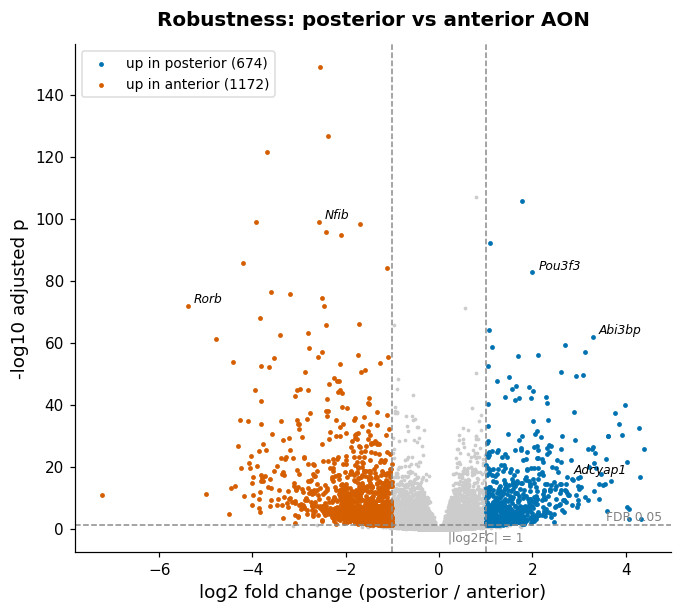

In [14]:
# Robustness check: posterior vs anterior (the dominant molecular axis). Re-run the paired DESeq2
# on the supertype grouping and report concordance with the dorsolateral primary, save as the
# robustness result.
adata_ap = adata.copy()
adata_ap.obs["group"] = adata_ap.obs["ap_group"]
pbc_ap, pbm_ap = build_pseudobulk(adata_ap)
res_ap, sig_ap, npd_ap, ns_ap, counts_ap, clin_ap = paired_deseq2(
    pbc_ap, pbm_ap, "posterior", "anterior")

shared_ap = set(sig.index) & set(sig_ap.index)
union_ap = set(sig.index) | set(sig_ap.index)
common = list(set(res.index) & set(res_ap.index))
sign_conc = np.mean(np.sign(res.loc[common, "log2FoldChange"])
                    == np.sign(res_ap.loc[common, "log2FoldChange"])) * 100
print(f"[3] Posterior/anterior robustness: {len(sig_ap)} sig genes ({npd_ap} paired donors)")
print(f"    Overlap with dorsolateral primary: {len(shared_ap)}  "
      f"Jaccard {len(shared_ap) / max(len(union_ap), 1):.3f}")
print(f"    Genome-wide sign concordance of log2FC (dorsolateral vs posterior): {sign_conc:.1f}%")

out_cols_ap = ["symbol", "log2FoldChange", "lfcSE", "pvalue", "padj", "baseMean"]
res_ap[out_cols_ap].to_csv(TAB_DIR / "de_posterior_vs_anterior_deseq2.csv")
sig_ap[out_cols_ap].to_csv(TAB_DIR / "de_significant_posterior_vs_anterior.csv")
fig = ps.volcano(res_ap, highlight=["Abi3bp", "Adcyap1", "Nfib", "Pou3f3", "Rorb"],
                 pos_label="posterior", neg_label="anterior",
                 title="Robustness: posterior vs anterior AON")
ps.save_fig(fig, FIG_DIR / "volcano_posterior_vs_anterior", close=False)
plt.show()

In [15]:
# Robustness: the prior Target (dorsolateral) / Non-target (ventromedial) sub-cluster
# lists. Projection-hypothesis-driven, not a clean spatial partition.
alt = pd.Series("other", index=adata.obs.index)
alt[adata.obs["cluster"].isin(alt_target_clusters)] = "dorsolateral"
alt[adata.obs["cluster"].isin(alt_nontarget_clusters)] = "ventromedial"
keep_alt = (alt != "other").values
adata_alt = adata[keep_alt].copy()
adata_alt.obs["group"] = pd.Categorical(alt[keep_alt].values,
                                        categories=["ventromedial", "dorsolateral"])
pbc_a, pbm_a = build_pseudobulk(adata_alt)
res_alt, sig_alt, npd_a, ns_a, _, _ = paired_deseq2(pbc_a, pbm_a, "dorsolateral", "ventromedial")

shared_a = set(sig.index) & set(sig_alt.index)
union_a = set(sig.index) | set(sig_alt.index)
common_a = list(set(res.index) & set(res_alt.index))
sign_a = np.mean(np.sign(res.loc[common_a, "log2FoldChange"])
                 == np.sign(res_alt.loc[common_a, "log2FoldChange"])) * 100
print(f"[4] Prior hand-list: {len(sig_alt)} sig genes  |  dorsolateral primary: {len(sig)}")
print(f"    Overlap {len(shared_a)}  Jaccard {len(shared_a) / max(len(union_a), 1):.3f}  "
      f"genome-wide sign-concordance {sign_a:.1f}%")
print("    Note: the hand-list labels 0175 (a dorsal Glut_3) as Non-target, which the coordinate")
print("    score places dorsolateral; the primary uses the reproducible coordinate definition.")

/Users/tisyasharma/opt/anaconda3/envs/cap_stable/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


/Users/tisyasharma/opt/anaconda3/envs/cap_stable/lib/python3.12/site-packages/pydeseq2/dds.py:822: UserWarning: The dispersion trend curve fitting did not converge. Switching to a mean-based dispersion trend.
  self._fit_parametric_dispersion_trend(vst)


[4] Prior hand-list: 1624 sig genes  |  dorsolateral primary: 1347
    Overlap 970  Jaccard 0.485  genome-wide sign-concordance 83.7%
    Note: the hand-list labels 0175 (a dorsal Glut_3) as Non-target, which the coordinate
    score places dorsolateral; the primary uses the reproducible coordinate definition.


## Cell-level testing and pseudoreplication

A cell-level Wilcoxon treats every nucleus as an independent observation, so the effective n
becomes the cell count (tens of thousands) rather than the donor count. Because nuclei from
the same mouse are correlated, this violates the independence assumption and is not a valid
test of a between-group difference at the level of animals (pseudoreplication).

Shown for transparency, not as a finding. It runs on log-normalized data with a different
test, so its hit count is not directly comparable to the DESeq2 count.

In [16]:
sc.tl.rank_genes_groups(
    viz, groupby="group", groups=["dorsolateral"], reference="ventromedial",
    method="wilcoxon", key_added="cell_level",
)
cell_res = sc.get.rank_genes_groups_df(viz, group="dorsolateral", key="cell_level")
cell_sig = cell_res[(cell_res["pvals_adj"] < FDR) & (cell_res["logfoldchanges"].abs() > LOG2FC)]
print(f"Cell-level Wilcoxon genes (NOT a valid replicate-level result): {len(cell_sig)} "
      f"over {viz.n_obs:,} nuclei")
print(f"Donor-level DESeq2 genes (valid, n={n_samples} pseudobulk samples): {len(sig)}")

Cell-level Wilcoxon genes (NOT a valid replicate-level result): 779 over 28,330 nuclei
Donor-level DESeq2 genes (valid, n=20 pseudobulk samples): 1347


## Volcano plot (primary: dorsolateral vs ventromedial)


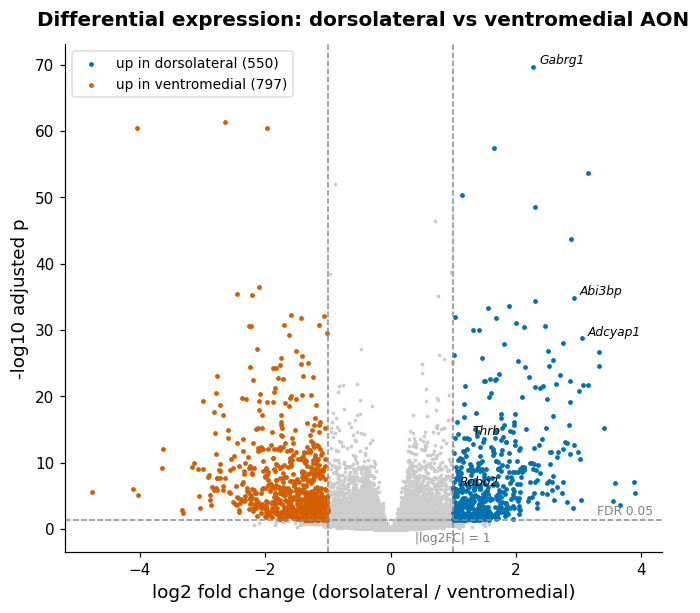

In [17]:
fig = ps.volcano(
    res,
    highlight=["Adcyap1", "Abi3bp", "Gabrg1", "Robo2", "Thrb", "Chrm3", "Rprm", "Cntn5"],
    pos_label="dorsolateral", neg_label="ventromedial",
    title="Differential expression: dorsolateral vs ventromedial AON",
)
ps.save_fig(fig, FIG_DIR / "volcano_dorsolateral_vs_ventromedial", close=False)
plt.show()


## Save results

In [18]:
out_cols = ["symbol", "log2FoldChange", "lfcSE", "pvalue", "padj", "baseMean"]
res[out_cols].to_csv(TAB_DIR / "de_dorsolateral_vs_ventromedial_deseq2.csv")
sig[out_cols].to_csv(TAB_DIR / "de_significant_dorsolateral_vs_ventromedial.csv")
print(f"Saved primary (dorsolateral vs ventromedial) results and {len(sig)} significant genes "
      f"to {TAB_DIR}")

Saved primary (dorsolateral vs ventromedial) results and 1347 significant genes to ../results/tables


## Candidate genes and DE diagnostics

Two candidate sets are kept distinct:

- **Set B (primary).** The eight projection-candidate markers defined a priori on the
  dorsolateral axis (Robo2, Abi3bp, Gabrg1, Adcyap1, Chrm3, Rprm, Thrb, Cntn5), ranked directly in
  this dorsolateral DESeq2 result with each gene's prior rationale and a support tier. Only
  Adcyap1 has direct primary-literature support in the AON, where it is glutamatergic and
  Slc17a7-co-expressing (Zhang et al. 2021, eLife). Robo2's canonical guidance role is the ipsilateral
  lateral olfactory tract, not commissural AON->AON. The other six are prior hypotheses.
  Robo2 belongs to this Set B list, not to the neuromodulation panel below.
- **Set A, the 118-gene neuromodulation/interneuron panel (supporting).**
  `data/aon_10x/Candidate_Genes.csv`, a broad cell-type-context panel (does not contain Robo2),
  ranked in the same result for context, clearly labelled supporting rather than the headline.

The canonical cortical projection panel is the negative control, and the diagnostics (MA plot,
per-donor pseudobulk PCA, mean-variance trend) confirm the result is not driven by a single donor or
a count-dependent bias.

Set B: 8/8 tested, 6 reach FDR < 0.05 (5 also clear |log2FC| > 1.0), 8/8 dorsolateral-enriched
 symbol  log2FoldChange  padj  significant                                                              support
Adcyap1           3.048 0.000         True                               direct AON support (Zhang et al. 2021, eLife)
 Abi3bp           2.923 0.000         True                                            prior hypothesis
 Gabrg1           2.273 0.000         True                                            prior hypothesis
   Thrb           1.212 0.000         True                                            prior hypothesis
  Robo2           1.001 0.000         True guidance receptor; in AON canonical role is ipsilateral LOT (caveat)
  Cntn5           0.720 0.190        False                                            prior hypothesis
   Rprm           0.660 0.095        False                                            prior hypothesis
  Chrm3           0.621 0.003        False     

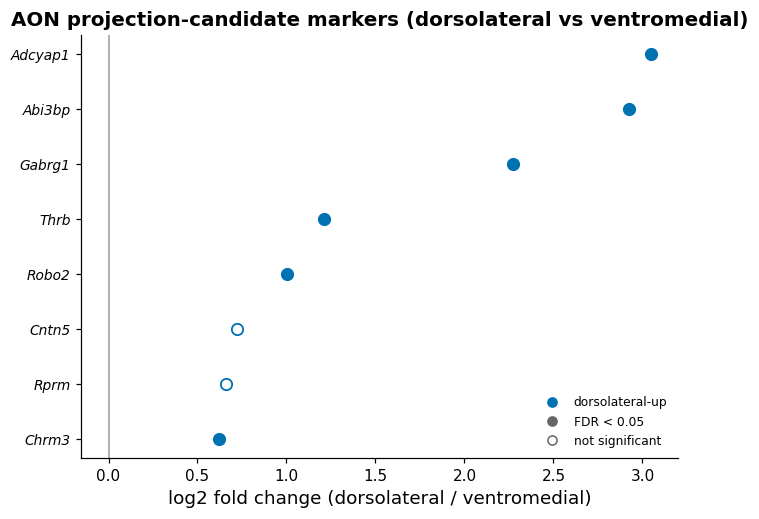

In [19]:
# Set B (primary): the 8 projection-candidate markers ranked in the dorsolateral result.
table12 = ["Robo2", "Abi3bp", "Gabrg1", "Adcyap1", "Chrm3", "Rprm", "Thrb", "Cntn5"]
table12_rationale = {
    "Robo2": "Slit/Robo axon-guidance receptor (ipsilateral LOT in AON)",
    "Abi3bp": "olfactory-system pyramidal marker (secreted)",
    "Gabrg1": "GABA-A receptor gamma1",
    "Adcyap1": "PACAP; enriched in AON VGLUT1 neurons",
    "Chrm3": "muscarinic M3; cholinoceptive AON neurons",
    "Rprm": "conserved olfactory marker",
    "Thrb": "thyroid hormone receptor beta",
    "Cntn5": "contactin-5; present but not AON-exclusive",
}
table12_support = {
    "Adcyap1": "direct AON support (Zhang et al. 2021, eLife)",
    "Robo2": "guidance receptor; in AON canonical role is ipsilateral LOT (caveat)",
    "Abi3bp": "prior hypothesis",
    "Gabrg1": "prior hypothesis",
    "Chrm3": "prior hypothesis",
    "Rprm": "prior hypothesis",
    "Thrb": "prior hypothesis",
    "Cntn5": "prior hypothesis",
}
setb = res[res["symbol"].isin(table12)].copy()
setb["direction"] = ps.direction_from_lfc(setb["log2FoldChange"], "dorsolateral", "ventromedial")
# fdr_sig is FDR-only; significant matches the headline rule (FDR and |log2FC| > cutoff) used for
# the 1,347-gene set and the candidate-set over-representation in 05_enrichment.
setb["fdr_sig"] = setb["padj"] < FDR
setb["significant"] = (setb["padj"] < FDR) & (setb["log2FoldChange"].abs() > LOG2FC)
setb["rationale"] = setb["symbol"].map(table12_rationale)
setb["support"] = setb["symbol"].map(table12_support)
setb = setb.sort_values("log2FoldChange", ascending=False)
setb.to_csv(TAB_DIR / "candidate_projection_de.csv")
n_sig_b = int(setb["fdr_sig"].sum())
n_sig_b_strict = int(setb["significant"].sum())
print(f"Set B: {len(setb)}/8 tested, {n_sig_b} reach FDR < {FDR} "
      f"({n_sig_b_strict} also clear |log2FC| > {LOG2FC}), "
      f"{(setb['log2FoldChange'] > 0).sum()}/{len(setb)} dorsolateral-enriched")
print(setb[["symbol", "log2FoldChange", "padj", "significant", "support"]].round(3).to_string(index=False))

fig = ps.candidate_effectsize(
    setb, pos_label="dorsolateral", neg_label="ventromedial",
    title="AON projection-candidate markers (dorsolateral vs ventromedial)", figsize=(7, 5))
ps.save_fig(fig, FIG_DIR / "candidate_gene_effectsize", close=False)
plt.show()

In [20]:
# Set A - the 118-gene neuromodulation/interneuron panel (supporting context, not the headline).
cand_panel = pd.read_csv(CANDIDATE_GENES)
cand_symbols = set(cand_panel["GeneName"].dropna().astype(str))
cand_de = res[res["symbol"].isin(cand_symbols)].copy()
cand_de["direction"] = ps.direction_from_lfc(cand_de["log2FoldChange"], "dorsolateral", "ventromedial")
# fdr_sig is FDR-only; significant matches the headline rule (FDR and |log2FC| > cutoff).
cand_de["fdr_sig"] = cand_de["padj"] < FDR
cand_de["significant"] = (cand_de["padj"] < FDR) & (cand_de["log2FoldChange"].abs() > LOG2FC)
cand_de = cand_de.sort_values("log2FoldChange", ascending=False)
cand_de.to_csv(TAB_DIR / "candidate_gene_de.csv")
n_sig_a = int(cand_de["fdr_sig"].sum())
n_sig_a_strict = int(cand_de["significant"].sum())
print(f"Set A (supporting, 118-gene panel): {len(cand_symbols)} genes, {len(cand_de)} tested, "
      f"{n_sig_a} reach FDR < {FDR} ({n_sig_a_strict} also clear |log2FC| > {LOG2FC}; "
      f"Robo2 is not in this panel)")

Set A (supporting, 118-gene panel): 118 genes, 108 tested, 50 reach FDR < 0.05 (27 also clear |log2FC| > 1.0; Robo2 is not in this panel)


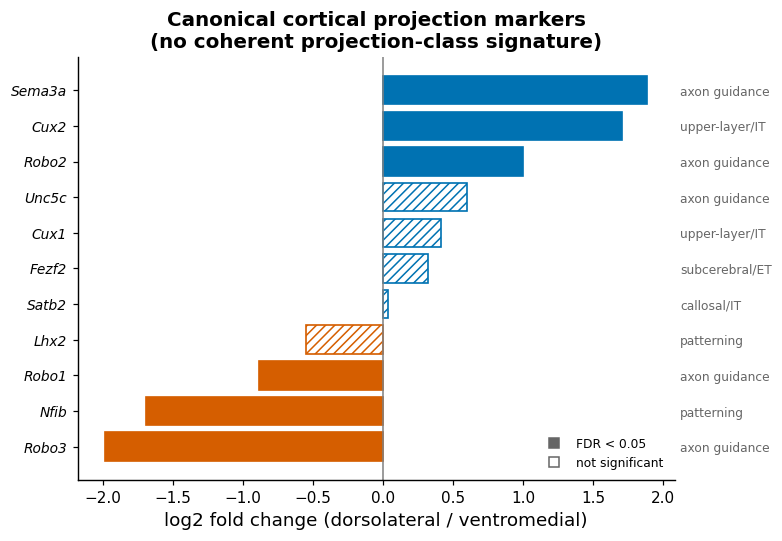

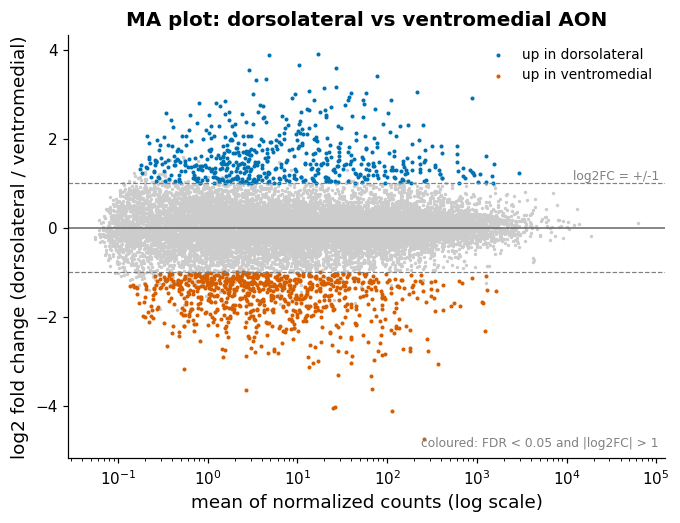

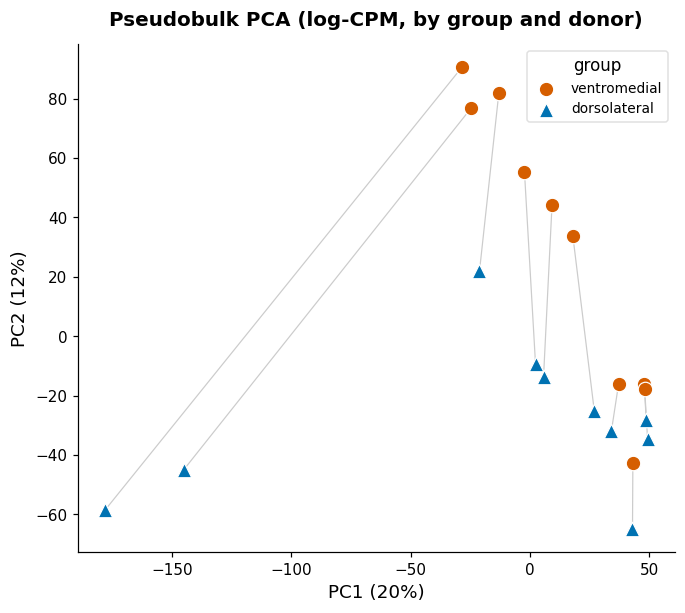

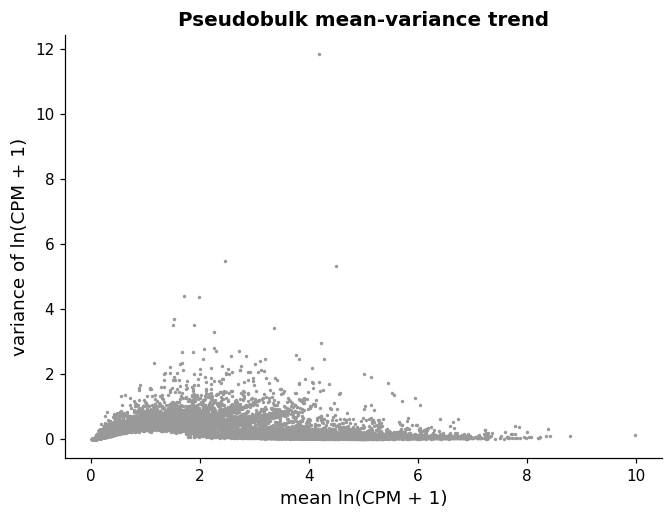

In [21]:
# Negative control + diagnostics on the dorsolateral primary result.
proj_syms = ["Satb2", "Cux1", "Cux2", "Lhx2", "Nfib", "Fezf2",
             "Robo1", "Robo2", "Robo3", "Unc5c", "Sema3a"]
proj_class = {"Satb2": "callosal/IT", "Cux1": "upper-layer/IT", "Cux2": "upper-layer/IT",
              "Lhx2": "patterning", "Nfib": "patterning", "Fezf2": "subcerebral/ET",
              "Robo1": "axon guidance", "Robo2": "axon guidance", "Robo3": "axon guidance",
              "Unc5c": "axon guidance", "Sema3a": "axon guidance"}
proj = res[res["symbol"].isin(proj_syms)][["symbol", "log2FoldChange", "padj"]].copy()
proj["class"] = proj["symbol"].map(proj_class)
fig = ps.projection_panel(
    proj, pos_label="dorsolateral", neg_label="ventromedial",
    title="Canonical cortical projection markers\n(no coherent projection-class signature)")
ps.save_fig(fig, FIG_DIR / "projection_panel", close=False)
plt.show()

fig = ps.ma_plot(res, pos_label="dorsolateral", neg_label="ventromedial",
                 title="MA plot: dorsolateral vs ventromedial AON")
ps.save_fig(fig, FIG_DIR / "de_diagnostics_ma", close=False)
plt.show()

pca_meta = clin[["donor", "group", "sex"]].copy()
pca_meta.index = counts.index
fig = ps.pseudobulk_pca(counts, pca_meta, title="Pseudobulk PCA (log-CPM, by group and donor)")
ps.save_fig(fig, FIG_DIR / "de_diagnostics_pca", close=False)
plt.show()

fig = ps.mean_variance(counts)
ps.save_fig(fig, FIG_DIR / "de_diagnostics_meanvar", close=False)
plt.show()
